# EDA — Dataset de Segmentacion de Cadera (100 pares imagen/mascara)

Explora `Imgs/` + `Msks_png/` (rutas en `../paths.toml`) **antes** de escribir el codigo de validacion o entrenamiento. Este notebook es independiente de `src/` a proposito (todavia no existe en este punto del desarrollo).

Objetivo:
1. Confirmar que imagen y mascara de cada par coinciden en tamaño
2. Ver la distribucion de clases (pixeles por clase)
3. Formato/canales/resoluciones
4. Detectar pares corruptos
5. Visualizar imagen + mascara superpuesta

In [21]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

if sys.version_info >= (3, 11):
    import tomllib
else:
    import tomli as tomllib

# Cargar rutas directamente desde paths.toml, sin depender de src/
with open("../paths.toml", "rb") as f:
    paths = tomllib.load(f)["data"]

IMAGES_DIR = paths["images_dir"]
MASKS_DIR = paths["masks_dir"]
DATASET_CSV = paths["dataset_csv"]
NUM_CLASSES = 5  # 0=fondo, 1-4 estructuras de cadera

sns.set_style("whitegrid")

In [22]:
PIL_MODE_TO_CHANNELS = {
    "1": 1, "L": 1, "I": 1, "F": 1,
    "RGB": 3, "YCbCr": 3, "LAB": 3, "HSV": 3,
    "RGBA": 4, "CMYK": 4,
}

def extract_pair_metadata(img_filepath, msk_filepath):
    """Abre imagen y mascara, extrae metadatos. Nunca lanza excepcion."""
    result = {
        "img_filepath": img_filepath, "msk_filepath": msk_filepath,
        "img_is_valid": False, "msk_is_valid": False,
        "img_format": None, "msk_format": None,
        "img_channels": None, "msk_channels": None,
        "img_width": None, "img_height": None,
        "msk_width": None, "msk_height": None,
        "msk_max_label": None, "msk_min_label": None,
        "error": None,
    }

    def _describe(filepath):
        if not os.path.isfile(filepath):
            return False, None, None, None, None, "No existe"
        try:
            with Image.open(filepath) as img:
                img.verify()
            with Image.open(filepath) as img:
                w, h = img.size
                fmt, mode = img.format, img.mode
                ch = PIL_MODE_TO_CHANNELS.get(mode) or len(img.convert("RGB").getbands())
            return True, fmt, ch, w, h, None
        except (UnidentifiedImageError, OSError, ValueError, SyntaxError) as exc:
            return False, None, None, None, None, f"{type(exc).__name__}: {exc}"

    img_valid, img_fmt, img_ch, img_w, img_h, img_err = _describe(img_filepath)
    result.update(img_is_valid=img_valid, img_format=img_fmt, img_channels=img_ch,
                  img_width=img_w, img_height=img_h)

    msk_valid, msk_fmt, msk_ch, msk_w, msk_h, msk_err = _describe(msk_filepath)
    result.update(msk_is_valid=msk_valid, msk_format=msk_fmt, msk_channels=msk_ch,
                  msk_width=msk_w, msk_height=msk_h)

    errors = [e for e in (img_err, msk_err) if e]
    if errors:
        result["error"] = " | ".join(errors)

    if msk_valid:
        try:
            arr = np.array(Image.open(msk_filepath))
            result["msk_max_label"] = int(arr.max())
            result["msk_min_label"] = int(arr.min())
        except Exception as exc:
            result["msk_is_valid"] = False
            result["error"] = f"{result['error'] + ' | ' if result['error'] else ''}No se pudo leer como array: {exc}"

    return result

## 1. Cargar el manifest y extraer metadatos de cada par

In [23]:
df_csv = pd.read_csv(DATASET_CSV)
print(f"Total de pares listados en dataset.csv: {len(df_csv)}")

rows = []
for _, row in df_csv.iterrows():
    img_fp = os.path.join(IMAGES_DIR, row["imgs"])
    msk_fp = os.path.join(MASKS_DIR, row["msks"])
    rows.append(extract_pair_metadata(img_fp, msk_fp))

df = pd.DataFrame(rows)
df.head()

Total de pares listados en dataset.csv: 100


,img_filepath,msk_filepath,img_is_valid,msk_is_valid,img_format,msk_format,img_channels,msk_channels,img_width,img_height,msk_width,msk_height,msk_max_label,msk_min_label,error
0,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,True,True,JPEG,PNG,3,1,640,640,640,640,4,0,None
1,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,True,True,JPEG,PNG,3,1,640,640,640,640,4,0,None
2,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,True,True,JPEG,PNG,3,1,640,640,640,640,4,0,None
3,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,True,True,JPEG,PNG,3,1,640,640,640,640,4,0,None
4,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,C:/Users/mario/OneDrive/Desktop/Data_hip_segme...,True,True,JPEG,PNG,3,1,640,640,640,640,4,0,None


## 2. Pares invalidos o desalineados

In [24]:
invalid = df[~(df["img_is_valid"] & df["msk_is_valid"])]
print(f"Pares con archivo corrupto: {len(invalid)} de {len(df)}")

valid = df[df["img_is_valid"] & df["msk_is_valid"]].copy()
mismatched = valid[(valid["img_width"] != valid["msk_width"]) | (valid["img_height"] != valid["msk_height"])]
print(f"Pares con imagen y mascara de tamaño distinto: {len(mismatched)}")

invalid[["img_filepath", "msk_filepath", "error"]]

Pares con archivo corrupto: 0 de 100
Pares con imagen y mascara de tamaño distinto: 0


,img_filepath,msk_filepath,error


## 3. Formatos, canales y resoluciones

In [25]:
print("Formatos de imagen:", valid["img_format"].value_counts().to_dict())
print("Formatos de mascara:", valid["msk_format"].value_counts().to_dict())
print("Canales de imagen:", valid["img_channels"].value_counts().to_dict())
print("Canales de mascara:", valid["msk_channels"].value_counts().to_dict())
print("\nResoluciones de imagen (ancho x alto):")
print(valid[["img_width", "img_height"]].describe())

Formatos de imagen: {'JPEG': 100}
Formatos de mascara: {'PNG': 100}
Canales de imagen: {3: 100}
Canales de mascara: {1: 100}

Resoluciones de imagen (ancho x alto):
       img_width  img_height
count      100.0       100.0
mean       640.0       640.0
std          0.0         0.0
min        640.0       640.0
25%        640.0       640.0
50%        640.0       640.0
75%        640.0       640.0
max        640.0       640.0


**Nota:** aunque las imagenes se abren como RGB (3 canales), el contenido real es escala de grises replicada en los 3 canales por igual -- es normal en radiografias exportadas a JPG.

## 4. Distribucion de clases (pixeles totales por clase, en TODO el dataset)

Lo mas importante del EDA para segmentacion: si el fondo (clase 0) domina demasiado, el modelo puede "hacer trampa" prediciendo casi siempre fondo. Por eso se evalua con Dice score por clase, no solo accuracy.

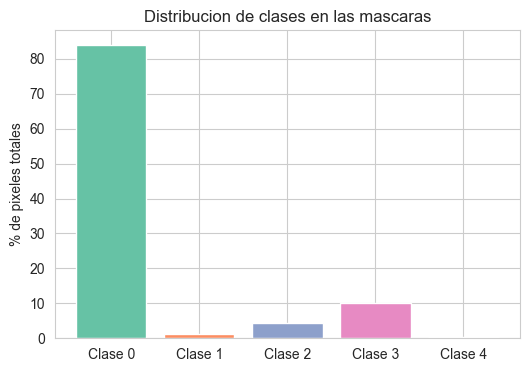

Clase 0: 83.95%
Clase 1: 1.22%
Clase 2: 4.30%
Clase 3: 10.17%
Clase 4: 0.36%


In [26]:
from collections import Counter

pixel_counter = Counter()
for fp in valid["msk_filepath"]:
    arr = np.array(Image.open(fp))
    for v, c in zip(*np.unique(arr, return_counts=True)):
        pixel_counter[int(v)] += int(c)

total_px = sum(pixel_counter.values())
dist = {f"Clase {k}": v / total_px * 100 for k, v in sorted(pixel_counter.items())}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dist.keys(), dist.values(), color=sns.color_palette("Set2"))
ax.set_ylabel("% de pixeles totales")
ax.set_title("Distribucion de clases en las mascaras")
plt.show()

for k, v in dist.items():
    print(f"{k}: {v:.2f}%")

## 5. Visualizacion: imagen + mascara superpuesta

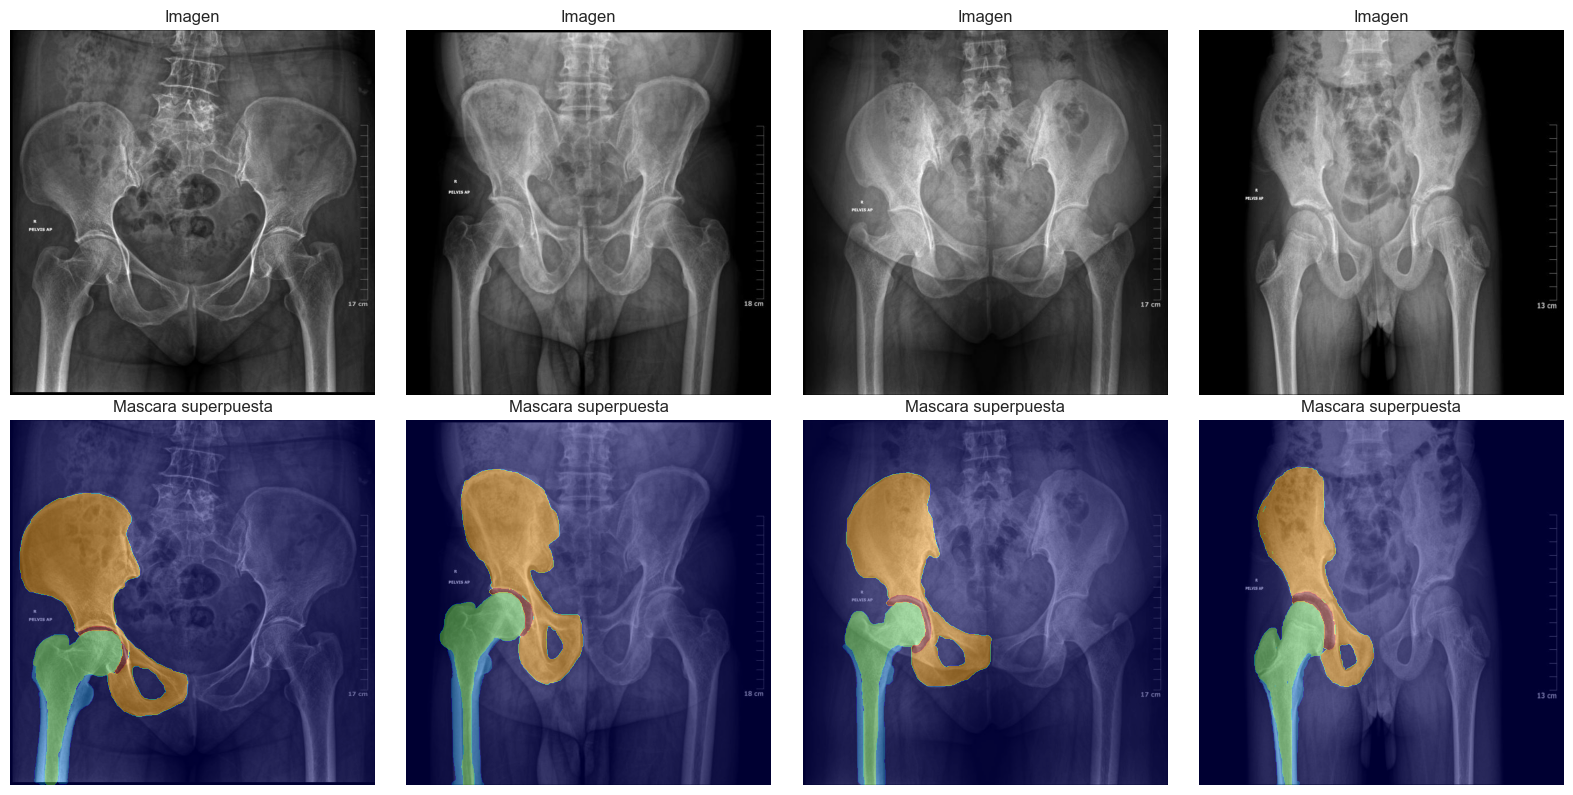

In [27]:
def show_overlay(n=4):
    sample = valid.sample(n, random_state=42)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    for i, (_, row) in enumerate(sample.iterrows()):
        img = np.array(Image.open(row["img_filepath"]).convert("L"))
        msk = np.array(Image.open(row["msk_filepath"]))

        axes[0, i].imshow(img, cmap="gray")
        axes[0, i].set_title("Imagen")
        axes[0, i].axis("off")

        axes[1, i].imshow(img, cmap="gray")
        axes[1, i].imshow(msk, cmap="jet", alpha=0.4)
        axes[1, i].set_title("Mascara superpuesta")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()

show_overlay()

## 7. Espectro de Fourier promedio (solo imagenes, no mascaras)

El espectro de Fourier muestra el contenido de frecuencias de la imagen: el centro concentra las frecuencias bajas (formas grandes y suaves, como el hueso y el fondo), y los bordes concentran las frecuencias altas (detalles finos, texturas, ruido). Promediarlo sobre todo el dataset muestra el patron de frecuencias tipico de tus radiografias.

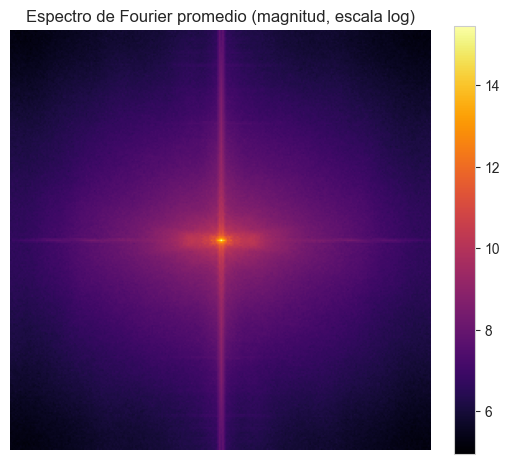

In [28]:
def compute_avg_fourier_spectrum(filepaths, size=256):
    spectra = []
    for fp in filepaths:
        img = np.array(Image.open(fp).convert("L").resize((size, size)), dtype=np.float32)
        f = np.fft.fft2(img)
        fshift = np.fft.fftshift(f)
        magnitude = np.log1p(np.abs(fshift))
        spectra.append(magnitude)
    return np.mean(spectra, axis=0)

avg_spectrum = compute_avg_fourier_spectrum(valid["img_filepath"].tolist())

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(avg_spectrum, cmap="inferno")
ax.set_title("Espectro de Fourier promedio (magnitud, escala log)")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## 8. Histograma de intensidades promedio (solo imagenes, no mascaras)

Muestra, en promedio, cuantos pixeles del dataset caen en cada nivel de gris (0=negro, 255=blanco). Util para saber si las imagenes estan bien expuestas/contrastadas o si conviene normalizar/ecualizar antes de entrenar.

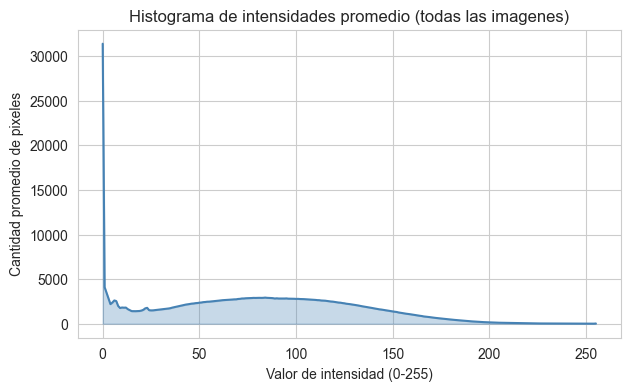

Intensidad media global: 78.51 (desviacion entre imagenes: 11.96)


In [29]:
def compute_avg_intensity_histogram(filepaths, bins=256):
    hist_accum = np.zeros(bins)
    means = []
    for fp in filepaths:
        img = np.array(Image.open(fp).convert("L"))
        hist, _ = np.histogram(img.ravel(), bins=bins, range=(0, 255))
        hist_accum += hist
        means.append(img.mean())
    return hist_accum / len(filepaths), np.array(means)

avg_hist, per_image_means = compute_avg_intensity_histogram(valid["img_filepath"].tolist())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(avg_hist, color="steelblue")
ax.fill_between(range(len(avg_hist)), avg_hist, alpha=0.3, color="steelblue")
ax.set_xlabel("Valor de intensidad (0-255)")
ax.set_ylabel("Cantidad promedio de pixeles")
ax.set_title("Histograma de intensidades promedio (todas las imagenes)")
plt.show()

print(f"Intensidad media global: {per_image_means.mean():.2f} (desviacion entre imagenes: {per_image_means.std():.2f})")

## 9. Ecualizacion por gradiente

Dado que el histograma de intensidades salio dominado por el fondo (pico grande cerca de 0), en vez de usar ecualizacion de histograma clasica o CLAHE, se probo una tecnica propia: en vez de ponderar la transformacion por CUANTOS pixeles hay en cada nivel de gris, se pondera por la MAGNITUD DEL GRADIENTE (Sobel en X e Y) de los pixeles en ese nivel. El fondo, al ser casi plano, aporta gradiente ~0 y casi no influye en la transformacion resultante -- el contraste se redistribuye hacia las zonas con bordes reales (contornos oseos).

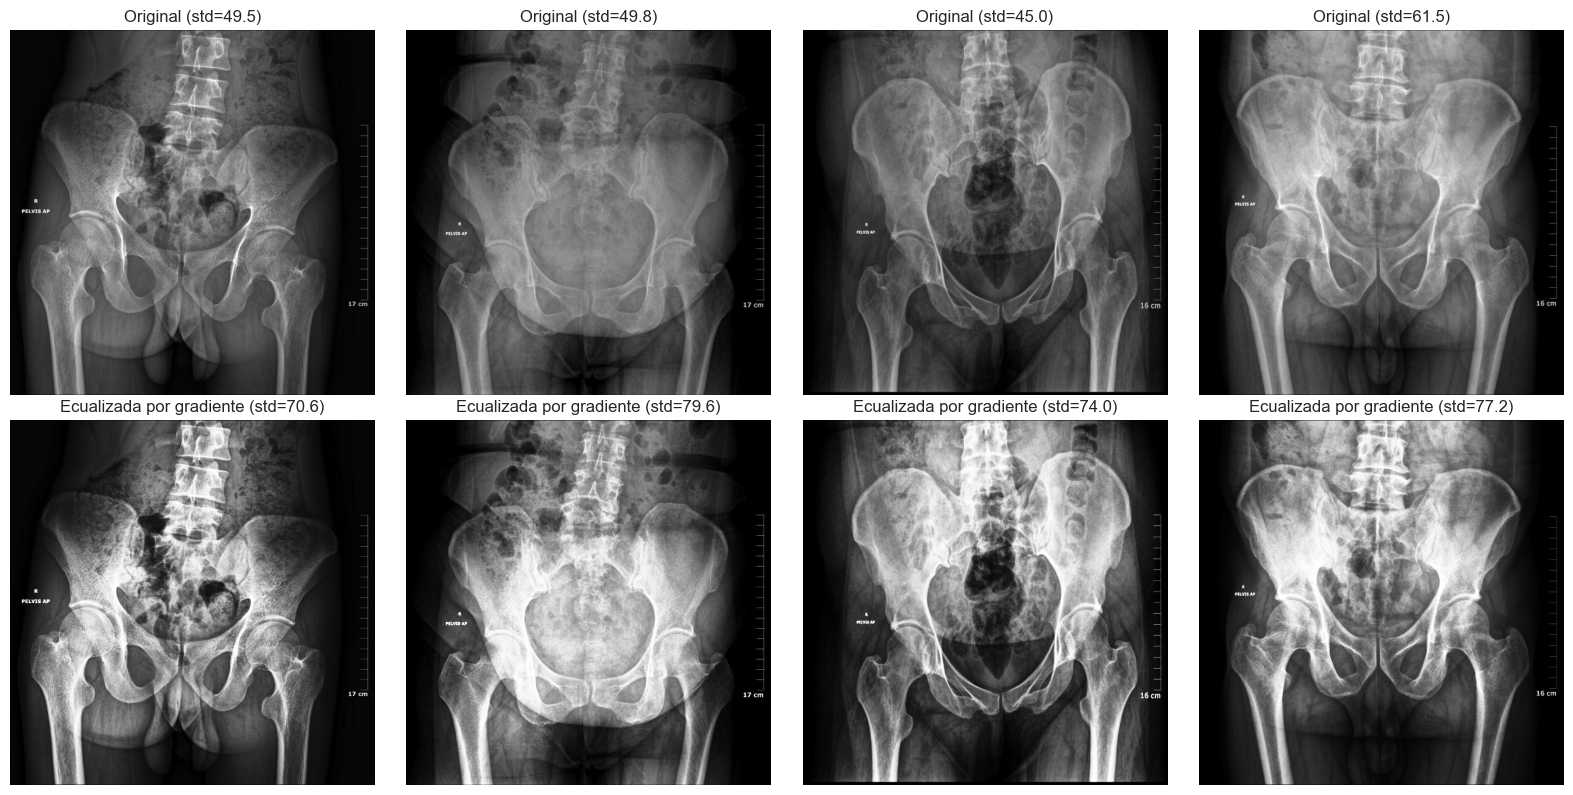

In [32]:
import cv2

def gradient_weighted_equalize(arr, bins=256):
    arr = arr.astype(np.uint8)
    gx = cv2.Sobel(arr, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(arr, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)

    weighted_hist = np.zeros(bins, dtype=np.float64)
    flat_intensities = arr.ravel().astype(np.int64)
    flat_mag = magnitude.ravel()
    np.add.at(weighted_hist, flat_intensities, flat_mag)

    weighted_hist += 1e-6
    cdf = np.cumsum(weighted_hist)
    cdf_norm = (cdf - cdf.min()) / (cdf.max() - cdf.min()) * (bins - 1)
    lut = np.clip(cdf_norm, 0, bins - 1).astype(np.uint8)
    return lut[arr]

def show_gradient_equalization_comparison(n=4):
    sample = valid.sample(n, random_state=7)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    for i, (_, row) in enumerate(sample.iterrows()):
        img = np.array(Image.open(row["img_filepath"]).convert("L"))
        equalized = gradient_weighted_equalize(img)

        axes[0, i].imshow(img, cmap="gray")
        axes[0, i].set_title(f"Original (std={img.std():.1f})")
        axes[0, i].axis("off")

        axes[1, i].imshow(equalized, cmap="gray")
        axes[1, i].set_title(f"Ecualizada por gradiente (std={equalized.std():.1f})")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()

show_gradient_equalization_comparison()

# Histrograma ecualziados vs original 

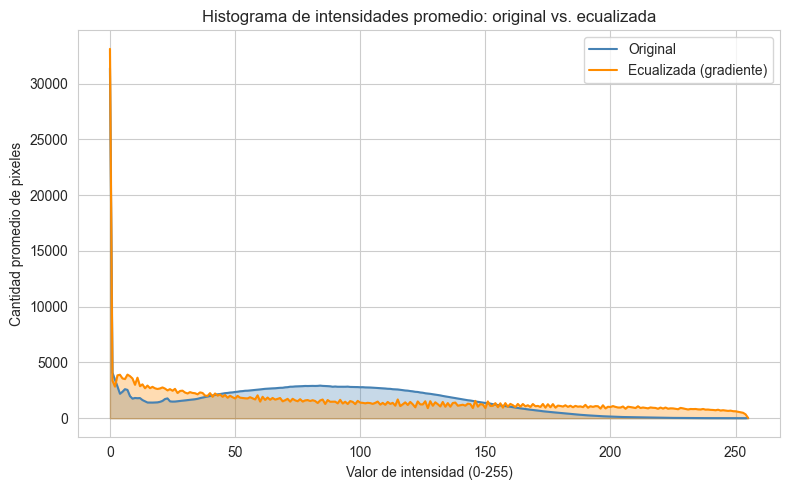

Pico en 0 (fondo) -> original: 31388, ecualizada: 33122


In [33]:
def compute_avg_intensity_histogram_equalized(filepaths, bins=256):
    hist_accum = np.zeros(bins)
    for fp in filepaths:
        img = np.array(Image.open(fp).convert("L"))
        eq = gradient_weighted_equalize(img)
        hist, _ = np.histogram(eq.ravel(), bins=bins, range=(0, 255))
        hist_accum += hist
    return hist_accum / len(filepaths)

avg_hist_equalized = compute_avg_intensity_histogram_equalized(valid["img_filepath"].tolist())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(avg_hist, color="steelblue", label="Original")
ax.fill_between(range(256), avg_hist, alpha=0.3, color="steelblue")
ax.plot(avg_hist_equalized, color="darkorange", label="Ecualizada (gradiente)")
ax.fill_between(range(256), avg_hist_equalized, alpha=0.3, color="darkorange")
ax.set_xlabel("Valor de intensidad (0-255)")
ax.set_ylabel("Cantidad promedio de pixeles")
ax.set_title("Histograma de intensidades promedio: original vs. ecualizada")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pico en 0 (fondo) -> original: {avg_hist[0]:.0f}, ecualizada: {avg_hist_equalized[0]:.0f}")